
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Your Name/2025 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [44]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

In [45]:
# Load my dataset using pandas Dataframe
gobike=pd.read_csv('fordgobike-tripdataFor201902.csv')
gobike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [46]:
# here we make overview in high-level for data shape and composition
data_shape = gobike.shape
print("Data Shape:", data_shape)
data_composition = gobike.info()
print("Data Composition:\n", data_composition)

Data Shape: (183416, 16)
<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  flo

In [47]:
## check each var  datatype 
gobike.dtypes


duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object

In [48]:
## I display 15 rows to understand the content values more 
gobike.head(15)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [49]:
# descriptive statistics for numeric variables
gobike.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [50]:
#the structure of the dataset contains 16 columns and 183416 rows
#most variables are numeric in nature
#What are the main interesting features in the dataset?
#The main interesting features in the dataset include:
#1. Duration_sec: This feature represents the duration of each bike trip in seconds, which is crucial for understanding the length of rides and user behavior.
#2. Start_time and End_time: These features provide insights into the timing of bike trips, allowing for analysis of peak usage hours and patterns.
#3. Start_station_name and End_station_name: These features indicate the locations where users start
#We got three main feature areas which are :
#1. Trip Details: This includes features like duration_sec, start_time, end_time, start_station_name, and end_station_name, which provide information about the specifics of each bike trip.
#2. User Information: This includes features like user_type, member_birth_year, and member_gender, which offer insights into the demographics and types of users utilizing the bike-sharing service.
#3. Bike Information: This includes features like bike_id and bike_share_for_all_trips, which provide details about the bikes themselves and their usage patterns.
#What features in the dataset supported my investigation for these interesting features?
#The features that supported my investigation for the interesting features include:
#1. Duration_sectrip durations,on user type or time of day.
#2. user_info: user_type, member_birth_year, and member_gender
#3. bike_info: bike_id and bike_share_for_all_trips




> ### What is the structure of your dataset?





- The structure of the dataset contains  16 columns and 183416 rows.
 
 
- Most variables are (numeric) in nature , and here are **dtypes summary :**

        - float64(7)
        - int64(2)
        - object(7)
        



> ### What are the main interesting features in the dataset?

#1. Duration_sec: This feature represents the duration of each bike trip in seconds, which is crucial for understanding the length of rides and user behavior.
#2. Start_time and End_time: These features provide insights into the timing of bike trips, allowing for analysis of peak usage hours and patterns.


 **We got three main feature areas which are :**
 
 
 


- #1. Trip Details: This includes features like duration_sec, start_time, end_time, start_station_name, and end_station_name, which provide information about the specifics of each bike trip.
 
 
 
- #2. User Information: This includes features like user_type, member_birth_year, and member_gender, which offer insights into the demographics and types of users utilizing the bike-sharing service.
 
  
 
  
- #3. Bike Information: This includes features like bike_id and bike_share_for_all_trips, which provide details about the bikes themselves and their usage patterns.





> ### What features in the dataset supported my investigation for these interesting features?





- #1. Duration_sectrip durations,on user type or time of day.



- #2. user_info: user_type, member_birth_year, and member_gender



- #3. bike_info: bike_id and bike_share_for_all_trips



-




- 




##  More Exploring ideas to begin my investigation

In [51]:
#This code for describing statistical data ideas in a more organized and readable table
organized_stats = gobike.describe().transpose()
print(organized_stats)


                            count         mean          std          min  \
duration_sec             183416.0   726.067311  1794.371831    61.000000   
start_station_id         183219.0   138.590365   111.778938     3.000000   
start_station_latitude   183416.0    37.771221     0.099586    37.317298   
start_station_longitude  183416.0  -122.352661     0.117100  -122.453705   
end_station_id           183219.0   136.249401   111.514916     3.000000   
end_station_latitude     183416.0    37.771425     0.099494    37.317298   
end_station_longitude    183416.0  -122.352247     0.116677  -122.453705   
bike_id                  183416.0  4472.890260  1664.386068    11.000000   
member_birth_year        175151.0  1984.806504    10.116589  1878.000000   

                                 25%          50%          75%           max  
duration_sec              325.000000   514.000000   796.000000  85444.000000  
start_station_id           47.000000   104.000000   239.000000    398.000000  
st

In [52]:
# display the information about each column
gobike.info()


<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [53]:
#yOUR CODES
missing_values = gobike.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64




> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with (mean) for numeric and (mode) for categorical

In [54]:
# # trying to fill missing values in my datset using for loop 
# for column in gobike.columns:
#     if gobike[column].isnull().sum() > 0:
#         if gobike[column].dtype == 'object':
#             gobike[column].fillna(gobike[column].mode()[0], inplace=True)
#         else:
#             gobike[column].fillna(gobike[column].mean(), inplace=True)


for column in gobike.columns:
    if gobike[column].isnull().sum() > 0:
        
        if pd.api.types.is_object_dtype(gobike[column]):
            gobike[column].fillna(gobike[column].mode()[0], inplace=True)
        
        elif pd.api.types.is_numeric_dtype(gobike[column]):
            gobike[column].fillna(gobike[column].mean(), inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_25732\2628621204.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  gobike[column].fillna(gobike[column].mean(), inplace=True)


In [55]:
#check the Nulls 
missing_values_after = gobike.isnull().sum()
print("Missing Values in Each Column After Filling:\n", missing_values_after)


Missing Values in Each Column After Filling:
 duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64


### **And with a proper category for other (member gender)**

In [56]:
##  still got a missing value in the member_gender, so let's explore this column more 
member_gender = gobike['member_gender'].isnull().sum()
print("Missing values in member_gender column:", member_gender)
# print(gbf.member_gender.head(15))

Missing values in member_gender column: 8265


In [57]:
# print(gbf.member_gender.head(15))
print(gobike['member_gender'].head(15))

0       Male
1        NaN
2       Male
3      Other
4       Male
5       Male
6     Female
7       Male
8      Other
9       Male
10    Female
11      Male
12      Male
13       NaN
14      Male
Name: member_gender, dtype: str


In [58]:
## check my result above 
check_result = gobike['member_gender'].isnull().sum()
print("Missing values in member_gender  column after filling:", check_result)


Missing values in member_gender  column after filling: 8265


> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [59]:
##  check duplicate in dataset
duplicate_rows = gobike.duplicated().sum()
print("Number of duplicate rows in the dataset:", duplicate_rows)


Number of duplicate rows in the dataset: 4


In [60]:
gobike.drop_duplicates(inplace=True)
duplicate_rows_after = gobike.duplicated().sum()
print("Number of duplicate rows after dropping duplicates:", duplicate_rows_after)


Number of duplicate rows after dropping duplicates: 0


> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [61]:
### check the category columns that included object
object_columns = gobike.select_dtypes(include=['object']).columns
print("Object Columns in the Dataset:\n", object_columns)

Object Columns in the Dataset:
 Index(['start_time', 'end_time', 'start_station_name', 'end_station_name',
       'user_type', 'member_gender', 'bike_share_for_all_trip'],
      dtype='str')


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25732\2883179081.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = gobike.select_dtypes(include=['object']).columns


 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [62]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.
gobike['user_type'] = gobike['user_type'].astype('category')
gobike['member_gender'] = gobike['member_gender'].astype('category')

In [63]:
## check your work 
gobike.dtypes

duration_sec                  int64
start_time                      str
end_time                        str
start_station_id            float64
start_station_name              str
start_station_latitude      float64
start_station_longitude     float64
end_station_id              float64
end_station_name                str
end_station_latitude        float64
end_station_longitude       float64
bike_id                       int64
user_type                  category
member_birth_year           float64
member_gender              category
bike_share_for_all_trip         str
dtype: object

In [64]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them
member_birth_year = gobike['member_birth_year'].describe()
print("Descriptive Statistics for member_birth_year:\n", member_birth_year)
# create a column for users' age depending on the current year
gobike['member_age'] = 2026 - gobike['member_birth_year']


Descriptive Statistics for member_birth_year:
 count    175147.000000
mean       1984.806437
std          10.116689
min        1878.000000
25%        1980.000000
50%        1987.000000
75%        1992.000000
max        2001.000000
Name: member_birth_year, dtype: float64


In [65]:
## check your work 
gobike['member_age'].describe()


count    175147.000000
mean         41.193563
std          10.116689
min          25.000000
25%          34.000000
50%          39.000000
75%          46.000000
max         148.000000
Name: member_age, dtype: float64

In [66]:
## change the new column age data type from float to int
gobike['member_age'] = gobike['member_age'].astype('Int64')
gobike['member_age'].info()


<class 'pandas.Series'>
RangeIndex: 183412 entries, 0 to 183411
Series name: member_age
Non-Null Count   Dtype
--------------   -----
175147 non-null  Int64
dtypes: Int64(1)
memory usage: 1.6 MB


In [67]:
## create a function to know the average users ages
def average_age(dataframe, age_column):
    average = dataframe[age_column].mean()
    return average
avg_age = average_age(gobike, 'member_age')
print("Average Age of Users:", avg_age)

Average Age of Users: 41.19356312126385


In [68]:
## another important factor to offer  marketing services is the trip duration time 
## need to change the time from second to minute to be more usable
duration_min = gobike['duration_sec'] / 60
gobike['duration_min']= gobike['duration_sec'] / 60
print(gobike['duration_sec'].head())
print('\n')
print(gobike['duration_min'].head())

0    52185
1    42521
2    61854
3    36490
4     1585
Name: duration_sec, dtype: int64


0     869.750000
1     708.683333
2    1030.900000
3     608.166667
4      26.416667
Name: duration_min, dtype: float64


In [69]:
## I need to change the time from second to Houre  to be more usable
gobike['duration_hour']= gobike['duration_sec'] / 3600
print(gobike['duration_sec'].head())
print('\n')
print(gobike['duration_hour'].head())

0    52185
1    42521
2    61854
3    36490
4     1585
Name: duration_sec, dtype: int64


0    14.495833
1    11.811389
2    17.181667
3    10.136111
4     0.440278
Name: duration_hour, dtype: float64



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

Text(0.5, 1.0, "Represent the user's distribution depending on user type")

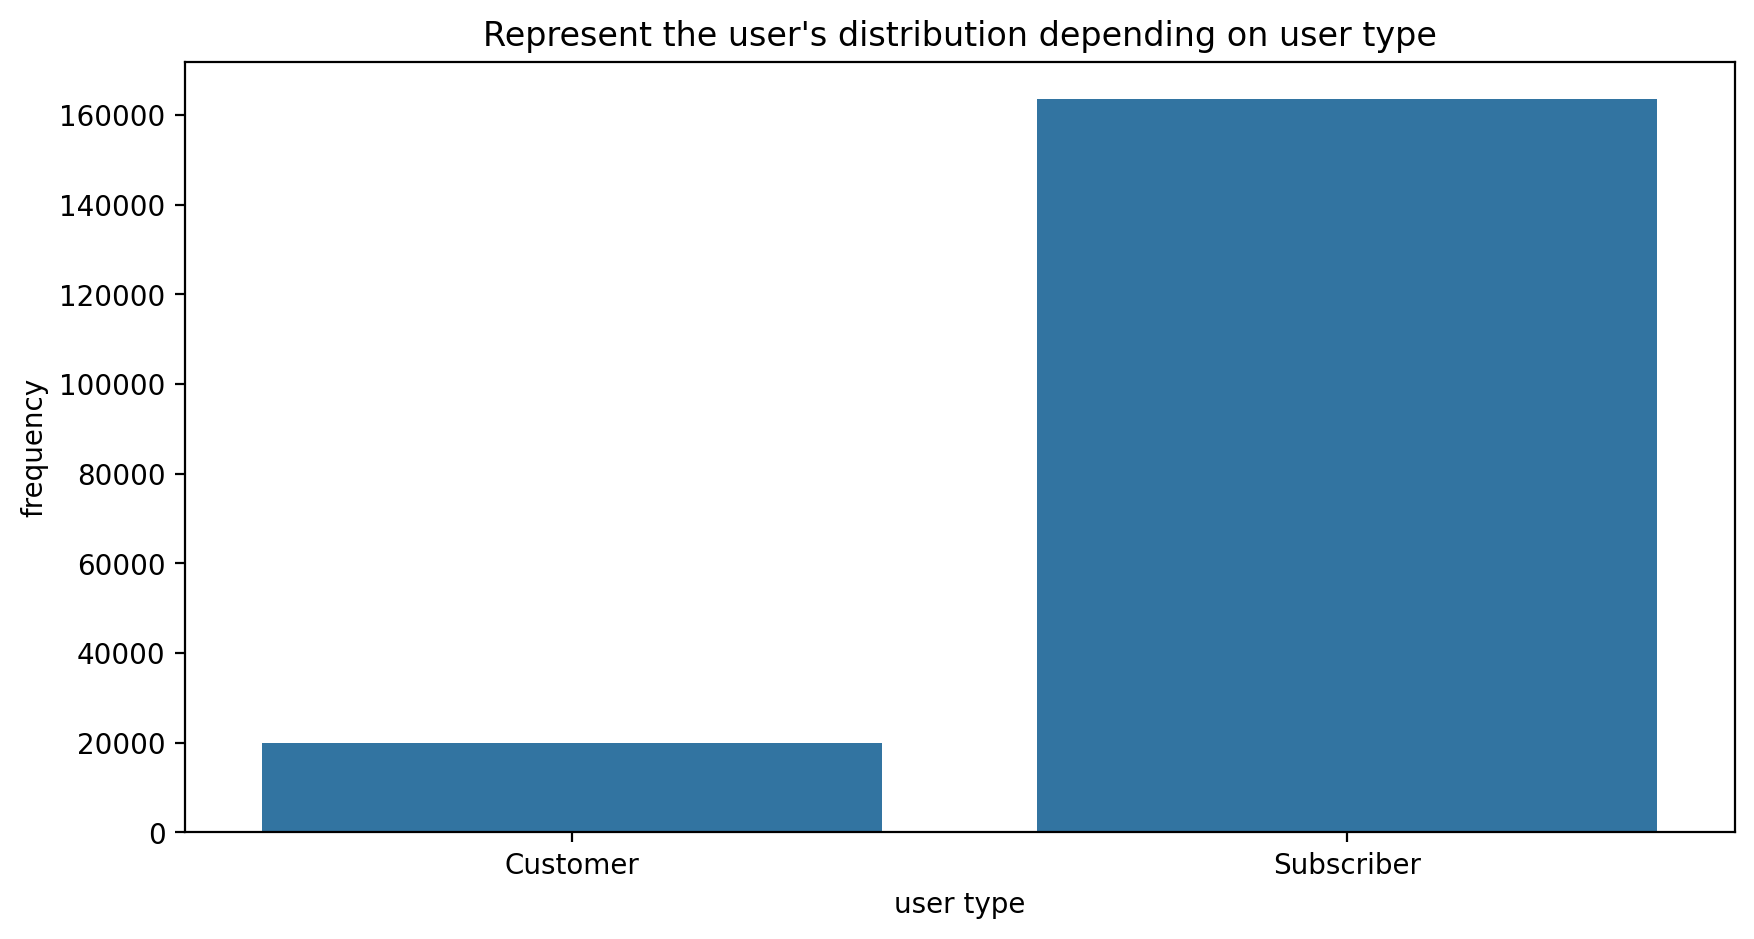

In [70]:
import seaborn as sns
plt.figure(figsize = (10,5), dpi = 200)
sb.countplot(data=gobike, x='user_type')
plt.xlabel('user type')
plt.ylabel('frequency')
plt.title("Represent the user's distribution depending on user type")

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

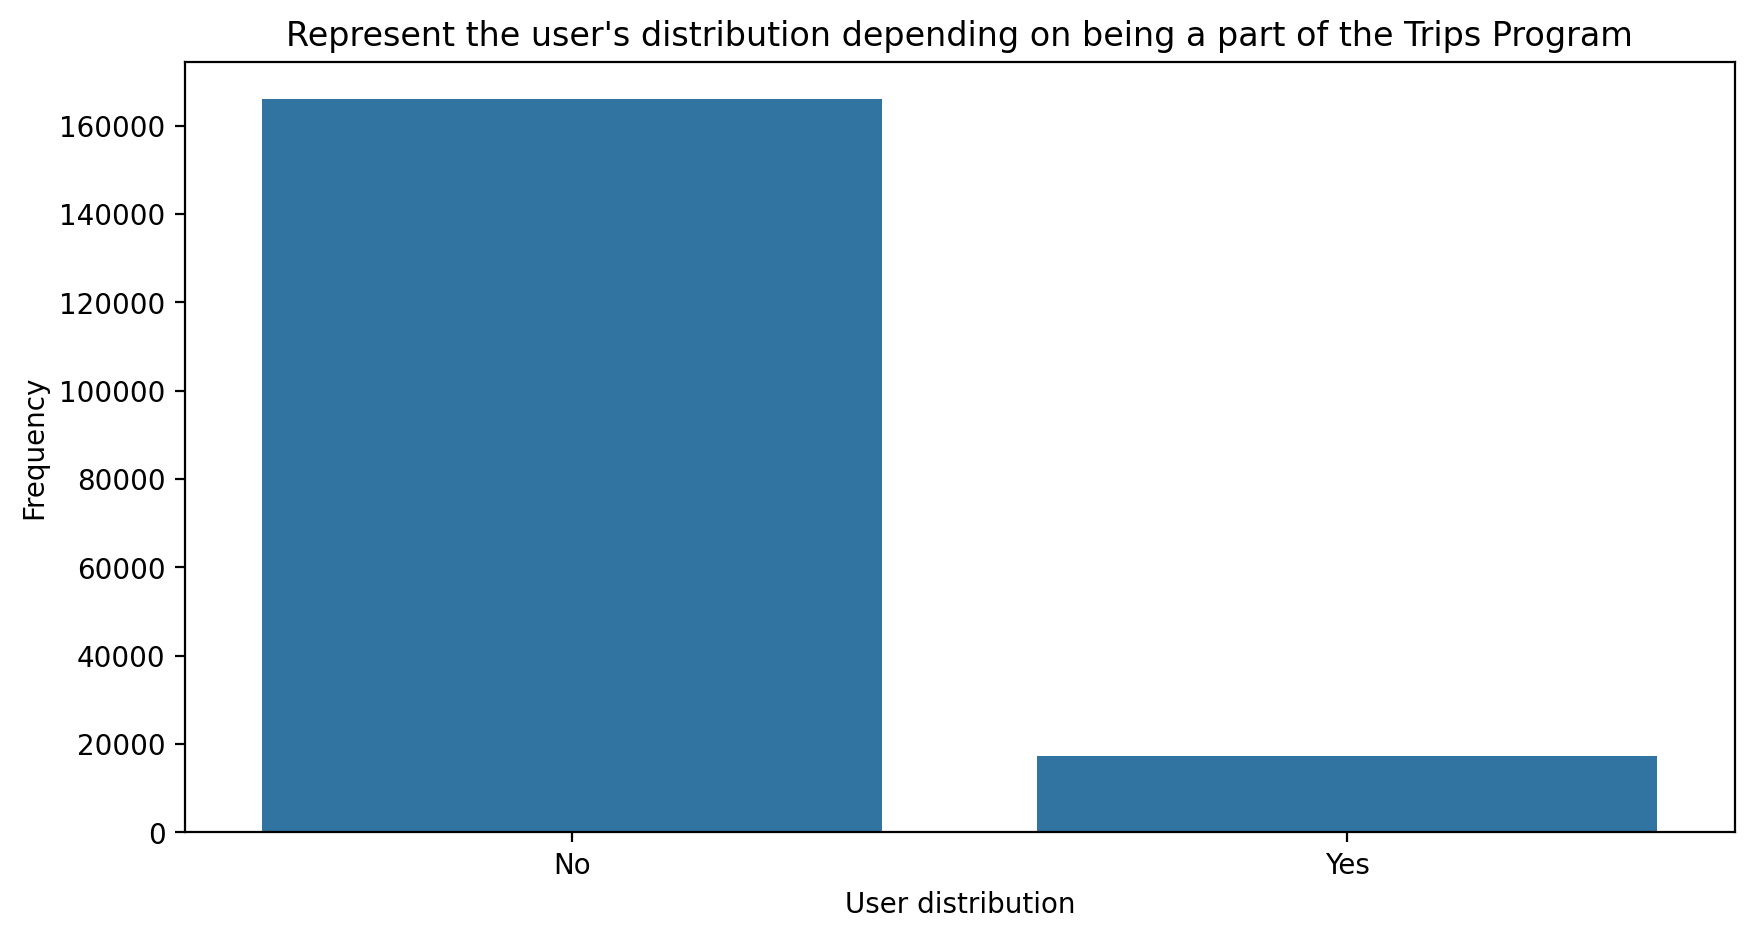

In [71]:
plt.figure(figsize = (10,5), dpi = 200)
plot = sns.countplot(data=gobike, x='bike_share_for_all_trip')
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.show()

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

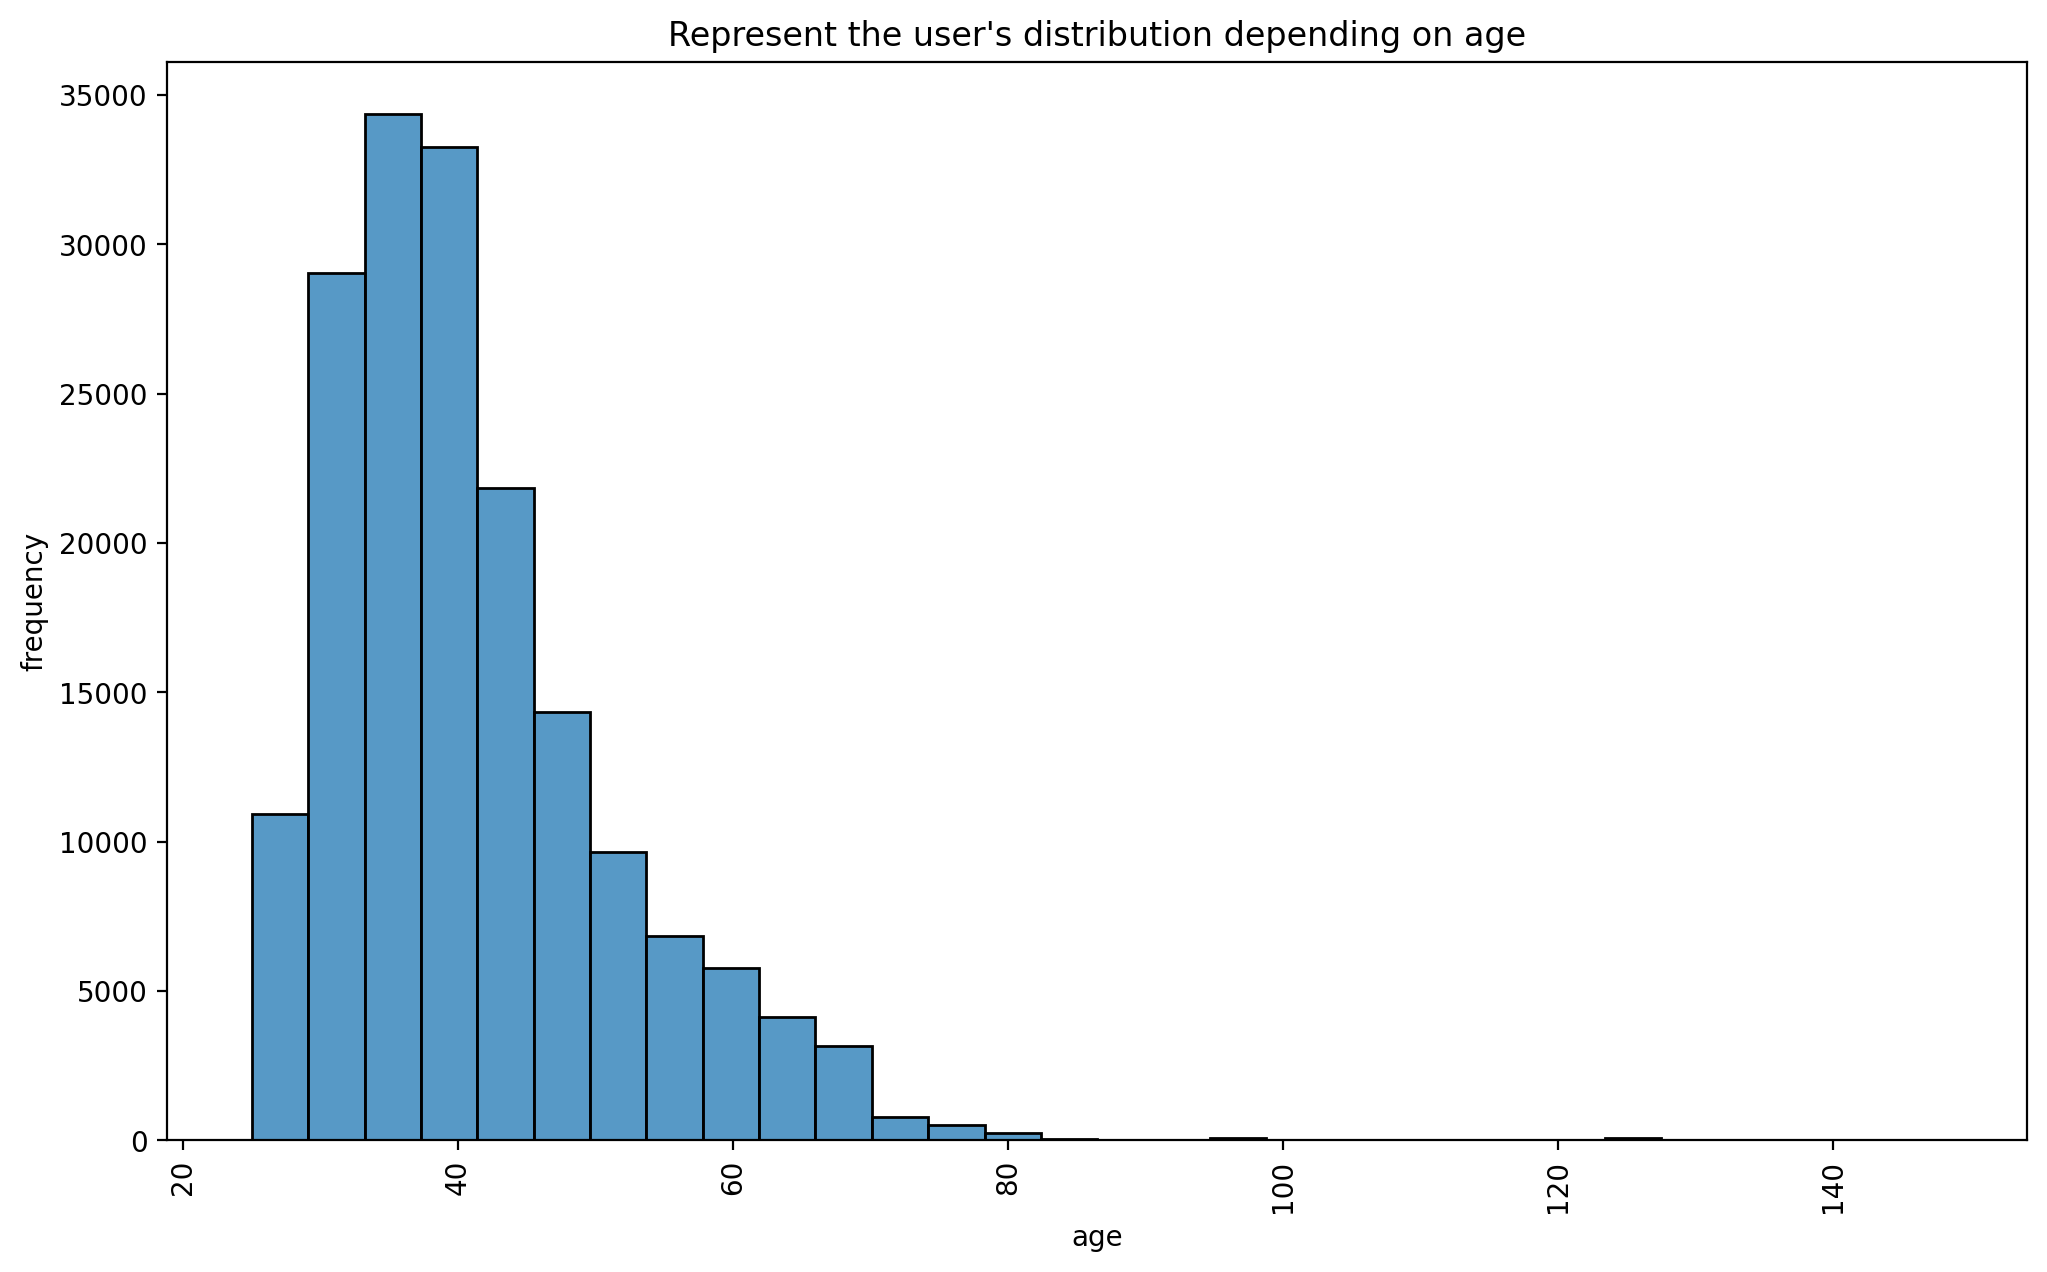

In [72]:
plt.figure(figsize = (12,7), dpi = 200)
sb.histplot(gobike['member_age'], bins=30)
plt.xlabel('age')
plt.ylabel('frequency')
plt.title("Represent the user's distribution depending on age")
plt.xticks(rotation=90)
plt.show()


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


In [73]:
Q1 = gobike['member_age'].quantile(0.25)
Q3 = gobike['member_age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = gobike[(gobike['member_age'] < lower_bound) | (gobike['member_age'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier ages: {list(outliers['member_age'])}")

Number of outliers: 5782
Outlier ages: [np.int64(67), np.int64(67), np.int64(67), np.int64(65), np.int64(65), np.int64(72), np.int64(68), np.int64(66), np.int64(66), np.int64(65), np.int64(70), np.int64(65), np.int64(65), np.int64(68), np.int64(68), np.int64(72), np.int64(66), np.int64(69), np.int64(81), np.int64(66), np.int64(66), np.int64(66), np.int64(69), np.int64(65), np.int64(67), np.int64(67), np.int64(70), np.int64(126), np.int64(66), np.int64(72), np.int64(72), np.int64(69), np.int64(66), np.int64(72), np.int64(74), np.int64(66), np.int64(78), np.int64(66), np.int64(68), np.int64(66), np.int64(66), np.int64(67), np.int64(66), np.int64(69), np.int64(69), np.int64(72), np.int64(68), np.int64(67), np.int64(69), np.int64(69), np.int64(66), np.int64(75), np.int64(85), np.int64(68), np.int64(65), np.int64(65), np.int64(75), np.int64(66), np.int64(81), np.int64(65), np.int64(70), np.int64(65), np.int64(81), np.int64(65), np.int64(66), np.int64(72), np.int64(65), np.int64(68), np.int6

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

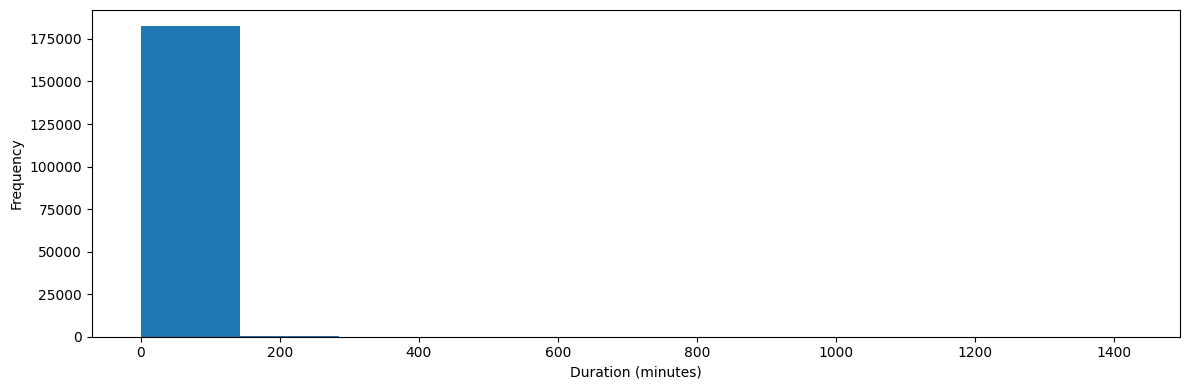

In [74]:
plt.figure(figsize=(12,4))
plt.hist(gobike['duration_min'])
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

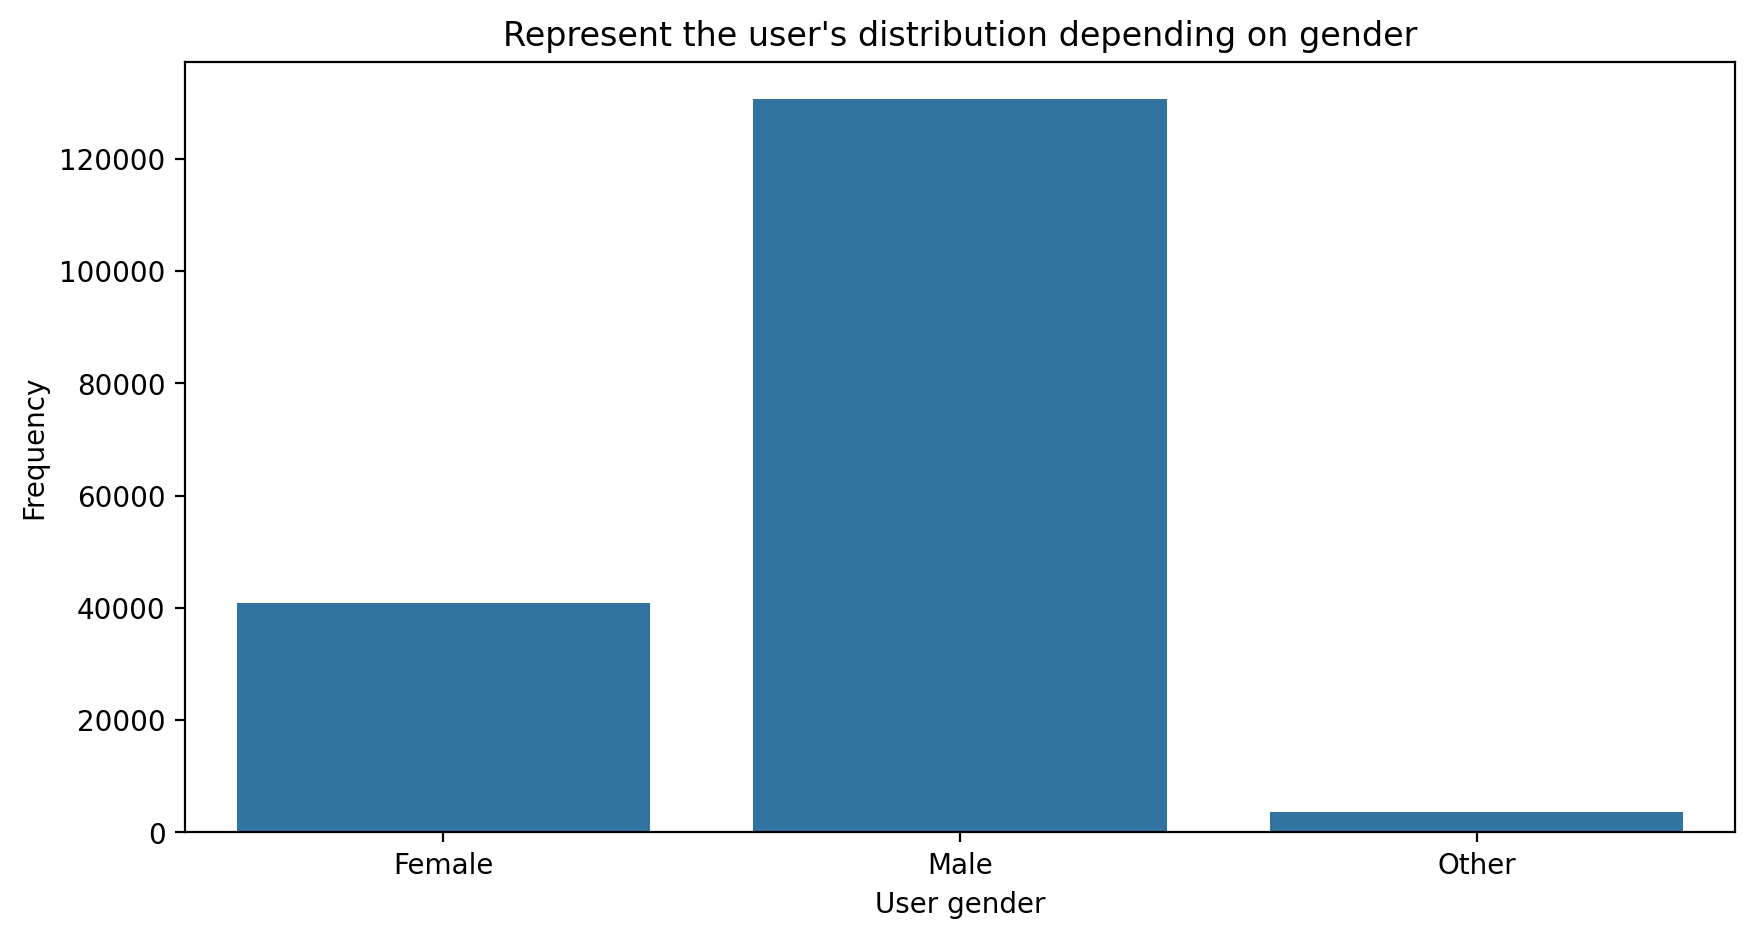

In [75]:
plt.figure(figsize = (10,5), dpi = 200)
plot = sns.countplot(data=gobike, x='member_gender')
plt.xlabel('User gender')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on gender")
plt.show()

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

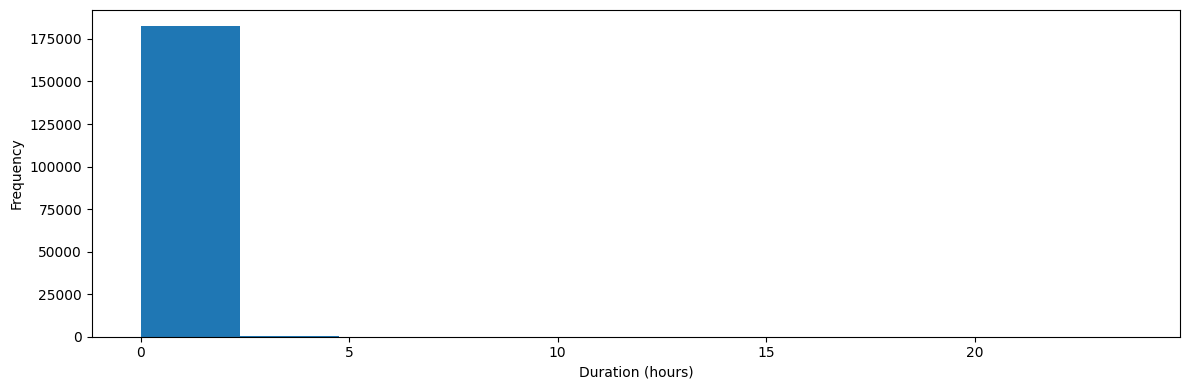

In [76]:
plt.figure(figsize=(12,4))
plt.hist(gobike['duration_hour'])
plt.xlabel("Duration (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [77]:
# Distribution of Age by user types
average_duration=gobike.groupby('user_type')['duration_min'].mean()
print(average_duration)

user_type
Customer      23.874417
Subscriber    10.671061
Name: duration_min, dtype: float64


# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

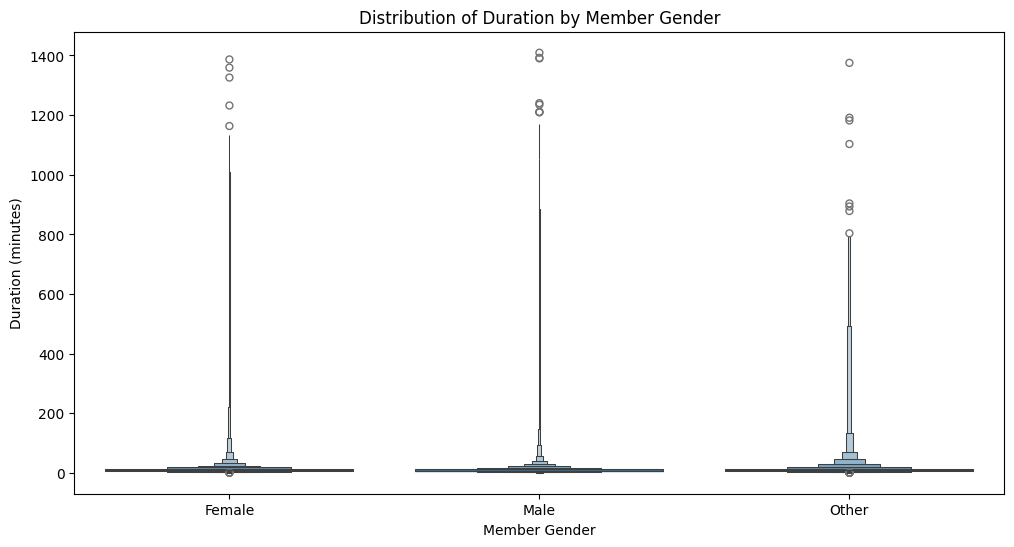

In [78]:
# Make visualization to easy get insight
plt.figure(figsize=(12,6))
sns.boxenplot(x='member_gender', y='duration_min', data=gobike)
plt.title('Distribution of Duration by Member Gender')
plt.xlabel('Member Gender')
plt.ylabel('Duration (minutes)')
plt.show()

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

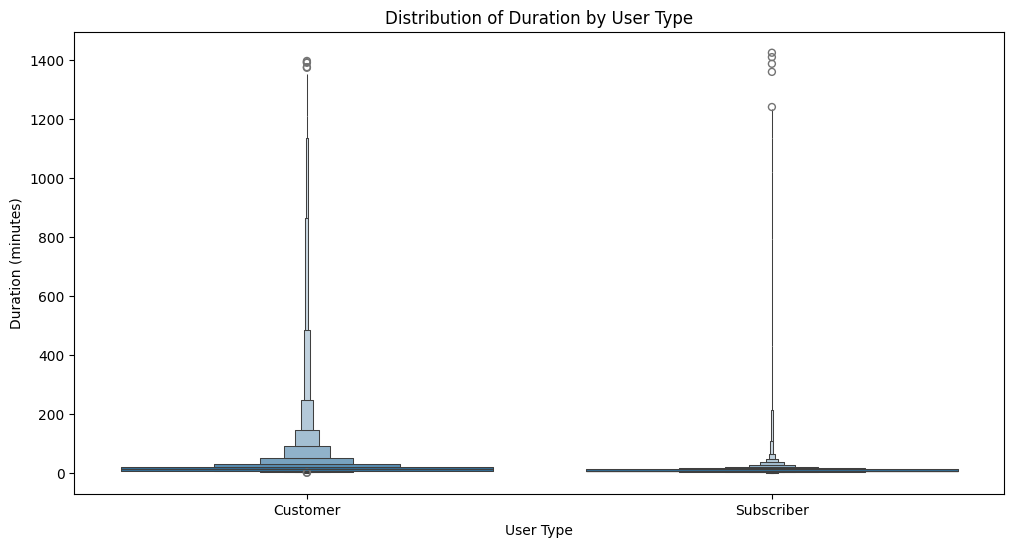

In [79]:
plt.figure(figsize=(12,6))
sns.boxenplot(x='user_type', y='duration_min', data=gobike)
plt.title('Distribution of Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration (minutes)')
plt.show()

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

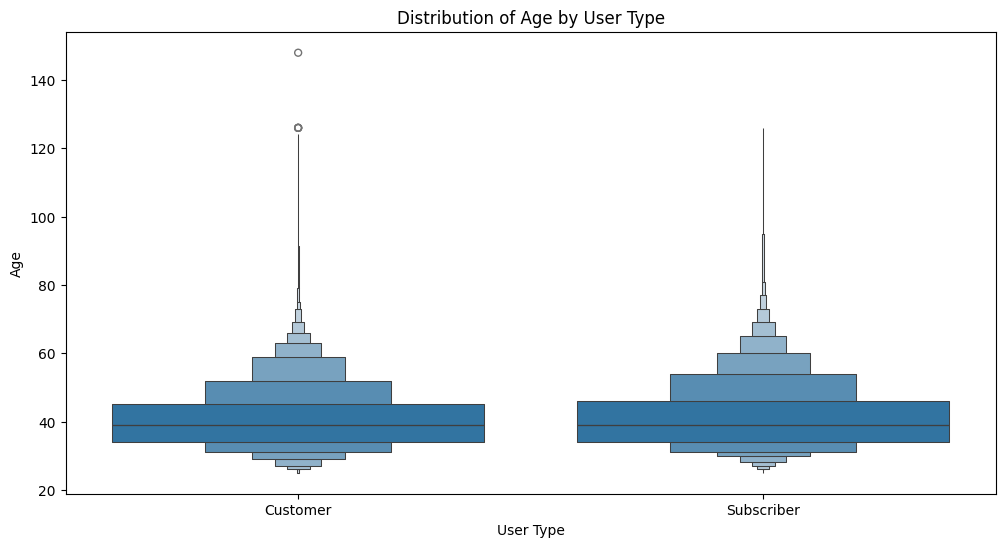

In [80]:
# Make visualization to easy get insight
plt.figure(figsize=(12,6))
sns.boxenplot(x='user_type', y='member_age', data=gobike)
plt.title('Distribution of Age by User Type')
plt.xlabel('User Type')
plt.ylabel('Age')
plt.show()

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

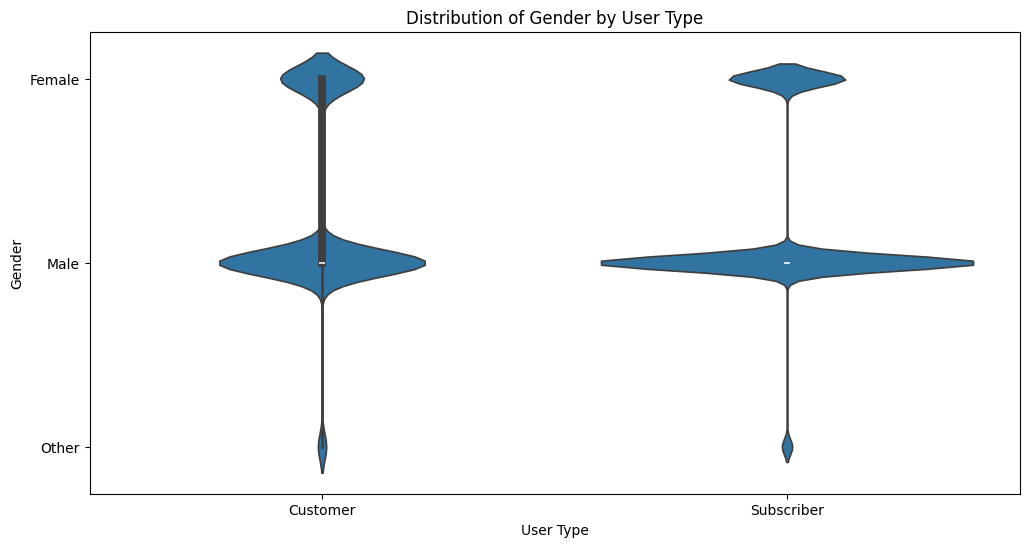

In [81]:
# Make visualization to easy get insight
plt.figure(figsize=(12,6))
sns.violinplot(x='user_type', y='member_gender', data=gobike)
plt.title('Distribution of Gender by User Type')
plt.xlabel('User Type')
plt.ylabel('Gender')
plt.show()

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Duration and User Type: The average duration of bike trips varied significantly between different user types. For instance, subscribers tended to have longer trip durations compared to customers, suggesting that subscribers might be using the service for commuting or longer recreational rides, while customers might be using it for shorter, more casual trips.


### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Age and Gender: The distribution of age varies by gender, with males generally having a wider age range compared to females.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

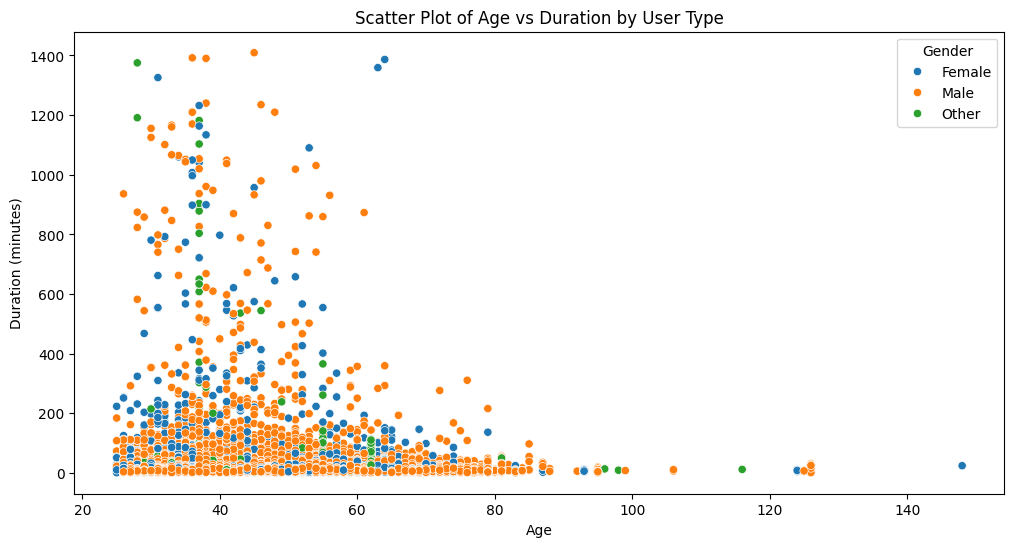

In [82]:
## Create plots of three or more variables to investigate your data even further. Make sure that your investigations are justified, and follow from your work in the previous sections.
plt.figure(figsize=(12,6))
sns.scatterplot(data=gobike,x='member_age', y='duration_min', hue='member_gender' )
plt.title('Scatter Plot of Age vs Duration by User Type')
plt.xlabel('Age')
plt.ylabel('Duration (minutes)')
plt.legend(title='Gender')
plt.show()


# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

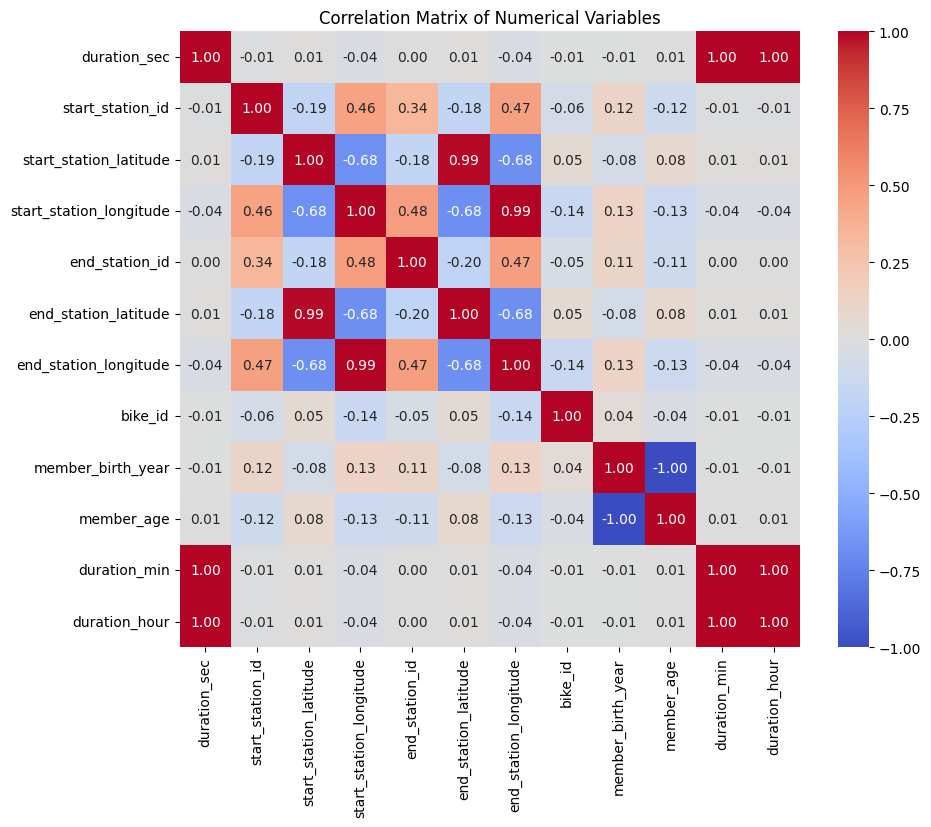

In [83]:
#Make visualization to easy get insight
#gobike = gobike.drop(columns=['duration_min', 'duration_hour'])
corr_matrix = gobike.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


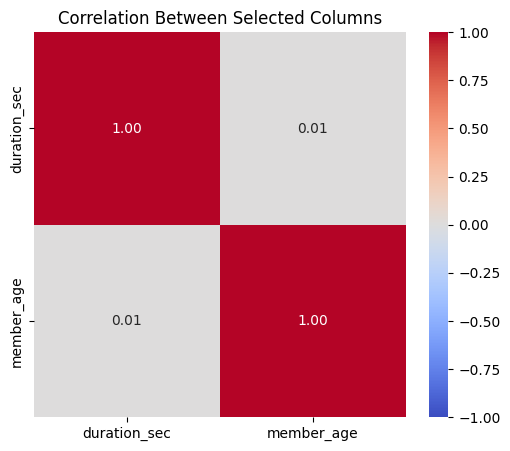

In [84]:
#Make visualization to easy get insight
cols = ['duration_sec', 'member_age']
corr_matrix = gobike[cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Between Selected Columns')
plt.show()

# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


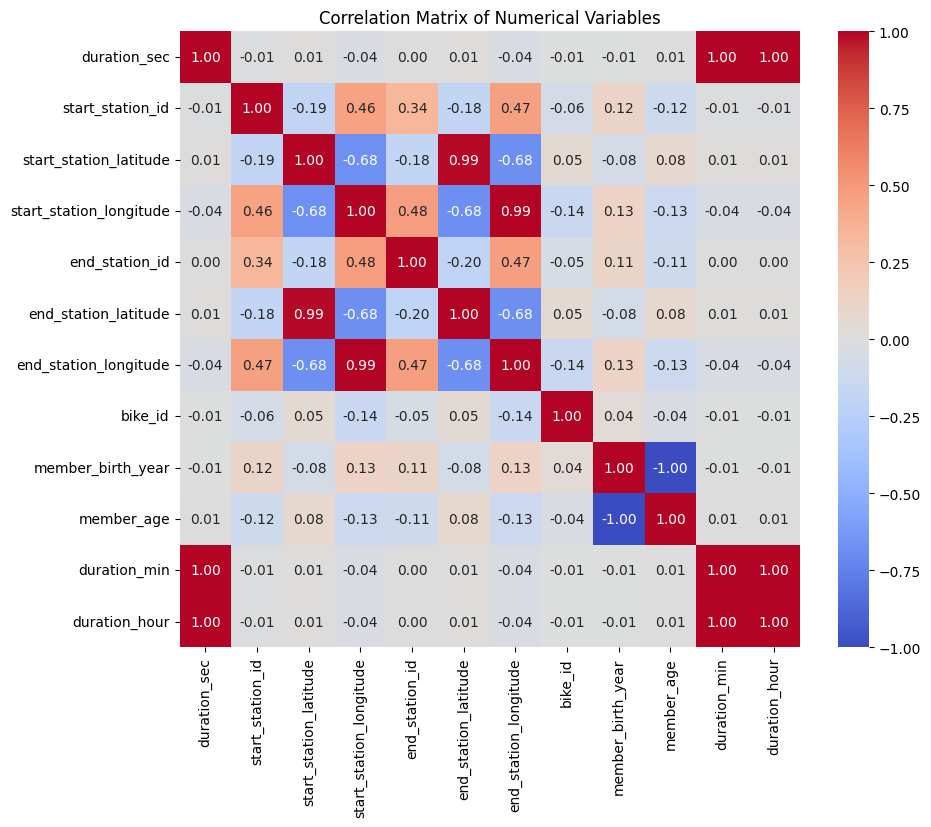

In [85]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight
corr_matrix = gobike.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male.


- most users were subscribers

- most users were between 20 and 40 years old

- duration of trips was mostly between 0 and 20 minutes, with a few outliers lasting much longer



## limitation 
example
- We got missing data which we fix some of them .

- we have outliers in the age column which we need to investigate more to know if we need to remove them or not
